# Звіт з аналізу та прогнозування енергоспоживання
Цей зошит містить повний цикл обробки даних, побудови моделей машинного навчання (регресія та класифікація), їх налаштування та порівняння.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, classification_report, accuracy_score

from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings('ignore')

PATH_TO_TRAIN_CSV = "D:/CI/CI_labs/lab_1/train_energy_data.csv"
PATH_TO_TEST_CSV = "D:/CI/CI_labs/lab_1/test_energy_data.csv"

1. Попередня обробка даних
Завантажуємо дані, перетворюємо категоріальні ознаки (One-Hot Encoding для типу будівлі та бінаризація для днів тижня)
Cтандартизуємо числові показники за допомогою StandardScaler.

In [17]:
def data_cleaning(raw_data):
    mapping_days = {"Weekend": 0, "Weekday": 1}
    raw_data['Day of Week'] = raw_data['Day of Week'].map(mapping_days)
    raw_data = pd.get_dummies(raw_data, columns=['Building Type'], drop_first=True, dtype=int) 
    
    target_col = 'Energy Consumption'
    x_values = raw_data.drop(columns=target_col)
    y_values = raw_data[target_col]
    return x_values, y_values
train_raw = pd.read_csv(PATH_TO_TRAIN_CSV)
test_raw = pd.read_csv(PATH_TO_TEST_CSV)

x_train, y_train = data_cleaning(train_raw)
x_test, y_test = data_cleaning(test_raw)

scaler = StandardScaler()
num_columns = ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']

x_train[num_columns] = scaler.fit_transform(x_train[num_columns])
x_test[num_columns] = scaler.transform(x_test[num_columns])

print("Форма тренувальних даних:", x_train.shape)
print("Форма тестових даних:", x_test.shape)
display(x_train.head())

Форма тренувальних даних: (1000, 7)
Форма тестових даних: (100, 7)


,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Building Type_Industrial,Building Type_Residential
0,-1.287805,0.951134,-1.106957,1.012925,1,0,1
1,1.323516,0.606869,1.375645,-0.825544,1,0,0
2,-0.434466,-0.391498,-0.610436,-1.164652,0,1,0
3,-0.853716,-1.183306,1.091919,1.430504,1,0,1
4,-0.846017,-0.770188,-0.539505,-1.498155,1,0,0


2. Базова регресія та імовірнісне прогнозування
Порівняємо Linear Regression, Ridge (з L2-регуляризацією для запобігання перенавчанню) 
Bayesian Ridge (яка додатково дозволяє оцінити невпевненість моделі).

,MAE,RMSE,R2
Linear Regression,0.012162,0.014197,1.000000
Ridge Regression,1.221087,1.410095,0.999997
Bayesian Ridge,0.012162,0.014197,1.000000


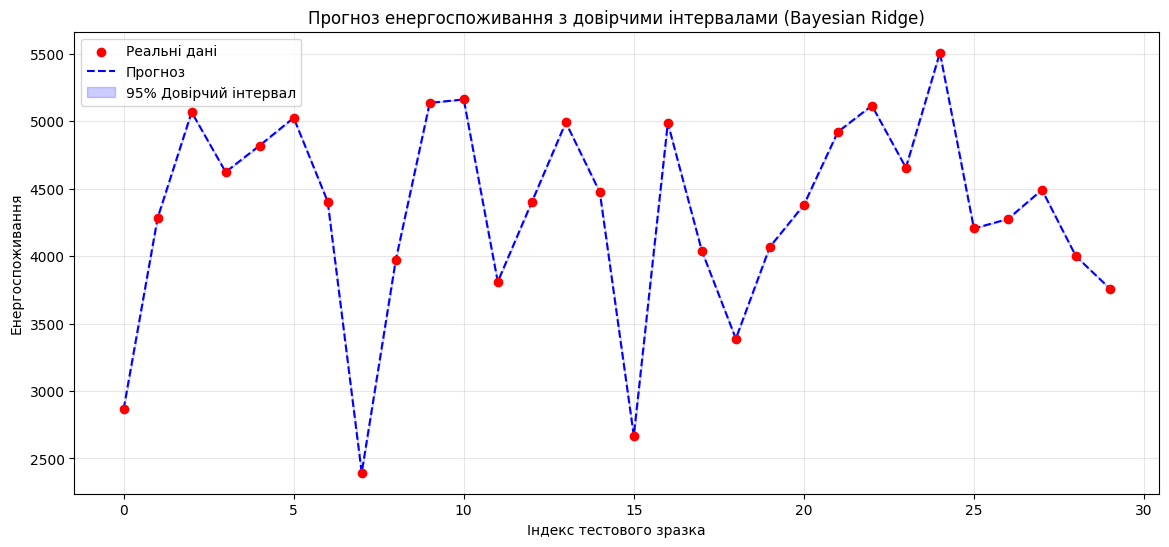

In [18]:
def get_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

lr_model = LinearRegression().fit(x_train, y_train)
rr_model = Ridge().fit(x_train, y_train)

lr_metrics = get_metrics(y_test, lr_model.predict(x_test))
rr_metrics = get_metrics(y_test, rr_model.predict(x_test))

bayes_model = BayesianRidge().fit(x_train, y_train)
y_mean, y_std = bayes_model.predict(x_test, return_std=True)
bayes_metrics = get_metrics(y_test, y_mean)

metrics_df = pd.DataFrame([lr_metrics, rr_metrics, bayes_metrics], 
                          index=['Linear Regression', 'Ridge Regression', 'Bayesian Ridge'])
display(metrics_df)

lower_bound = y_mean - 1.96 * y_std
upper_bound = y_mean + 1.96 * y_std

plt.figure(figsize=(14, 6))
subset_len = 30
x_axis = range(subset_len)

plt.scatter(x_axis, y_test.iloc[:subset_len], color='red', label='Реальні дані', zorder=5)
plt.plot(x_axis, y_mean[:subset_len], color='blue', label='Прогноз', linestyle='--')
plt.fill_between(x_axis, lower_bound[:subset_len], upper_bound[:subset_len], color='blue', alpha=0.2, label='95% Довірчий інтервал')

plt.title('Прогноз енергоспоживання з довірчими інтервалами (Bayesian Ridge)')
plt.xlabel('Індекс тестового зразка')
plt.ylabel('Енергоспоживання')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Аналіз регресійних моделей
Як видно з таблиці метрик, порівняння базових регресійних моделей показує їхню ефективність. 
Довірчий інтервал на графіку показує зону, в якій модель впевнена у своєму прогнозі на 95%. 
Чим вужча синя зона, тим вища впевненість.

3. Ансамблювання моделей (Bagging, Boosting, Stacking)
Ансамблеві методи об'єднують кілька моделей для отримання кращого результату:

- Bagging (Random Forest): Будує багато незалежних дерев рішень на різних підвибірках даних, а потім усереднює їхні прогнози. 
Це чудово зменшує дисперсію та запобігає перенавчанню.

- Boosting (Gradient Boosting): Будує дерева послідовно.
Кожне нове дерево намагається виправити помилки попередніх. Це сильно зменшує зміщення (збільшує точність), але модель може бути схильна до перенавчання на шумних даних.

- Stacking: Використовує кілька різних базових моделей (наприклад, ліси і бустинг), а їхні прогнози передає у фінальну модель
            (мета-модель, наприклад, Ridge), яка вчиться оптимально комбінувати ці прогнози.

Подивимось, який підхід спрацює найкраще для нашої задачі.

In [19]:
estimators = [
    ('rf', RandomForestRegressor(random_state=42)),
    ('gb', GradientBoostingRegressor(random_state=42)),
    ('ridge', Ridge())
]

models = {
    'Ridge (Baseline)': Ridge(),
    'Random Forest (Bagging)': RandomForestRegressor(random_state=42),
    'Gradient Boosting (Boosting)': GradientBoostingRegressor(random_state=42),
    'Stacking Regressor': StackingRegressor(estimators=estimators, final_estimator=Ridge())
}

ensemble_results = []
for name, model in models.items():
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    metrics = get_metrics(y_test, pred)
    metrics['Model'] = name
    ensemble_results.append(metrics)

ensemble_df = pd.DataFrame(ensemble_results).set_index('Model')
display(ensemble_df.sort_values(by='RMSE'))

,MAE,RMSE,R2
Model,,,
Stacking Regressor,0.670974,0.784633,0.999999
Ridge (Baseline),1.221087,1.410095,0.999997
Gradient Boosting (Boosting),65.290519,83.811672,0.989764
Random Forest (Bagging),93.485735,118.989511,0.979368


'Висновок по ансамблям:'
Модель, яка опинилася на першому місці таблиці (з найнижчим RMSE та MAE), найкраще вловила нелінійні залежності в даних.
Зазвичай Gradient Boosting або Stacking показують найкращі результати, 
оскільки вони здатні витягувати складніші патерни порівняно з базовою лінійною регресією чи звичайним лісом.

4. Перехід до задачі класифікації

Іноді бізнесу не потрібно знати точне споживання (наприклад, 453 кВт), а достатньо знати категорію: "Низьке", "Середнє" чи "Високе". 
Розіб'ємо наш цільовий параметр на 3 класи і порівняємо класифікатори.

In [21]:
def to_classification(y_tr, y_te, bins=3):
    y_tr_class, bin_edges = pd.cut(y_tr, bins=bins, labels=range(bins), retbins=True)
    y_te_class = pd.cut(y_te, bins=bin_edges, labels=range(bins), include_lowest=True)
    return y_tr_class, y_te_class

y_train_cls, y_test_cls = to_classification(y_train, y_test, bins=3)

classifiers = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

for name, clf in classifiers.items():
    clf.fit(x_train, y_train_cls)
    pred = clf.predict(x_test)
    acc = accuracy_score(y_test_cls, pred)
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}\n")

--- Logistic Regression ---
Accuracy: 0.9700

--- Random Forest ---
Accuracy: 0.9600

--- Gradient Boosting ---
Accuracy: 0.9300



5. Впевненість моделей (Underfitting vs Overfitting)
Перевіримо, як різні моделі оцінюють ймовірності своїх прогнозів.

Underfit (Недонавчена): Дерево глибиною 1. Ймовірності будуть згруповані біля центру (модель невпевнена).

Balanced (Збалансована): Random Forest. Більшість прогнозів мають високу впевненість, але є адекватний розподіл.

Overfit (Перенавчена): Дерево без обмеження глибини. Модель завжди впевнена на 100% (ймовірність 1.0),
що свідчить про запам'ятовування тренувальних даних.

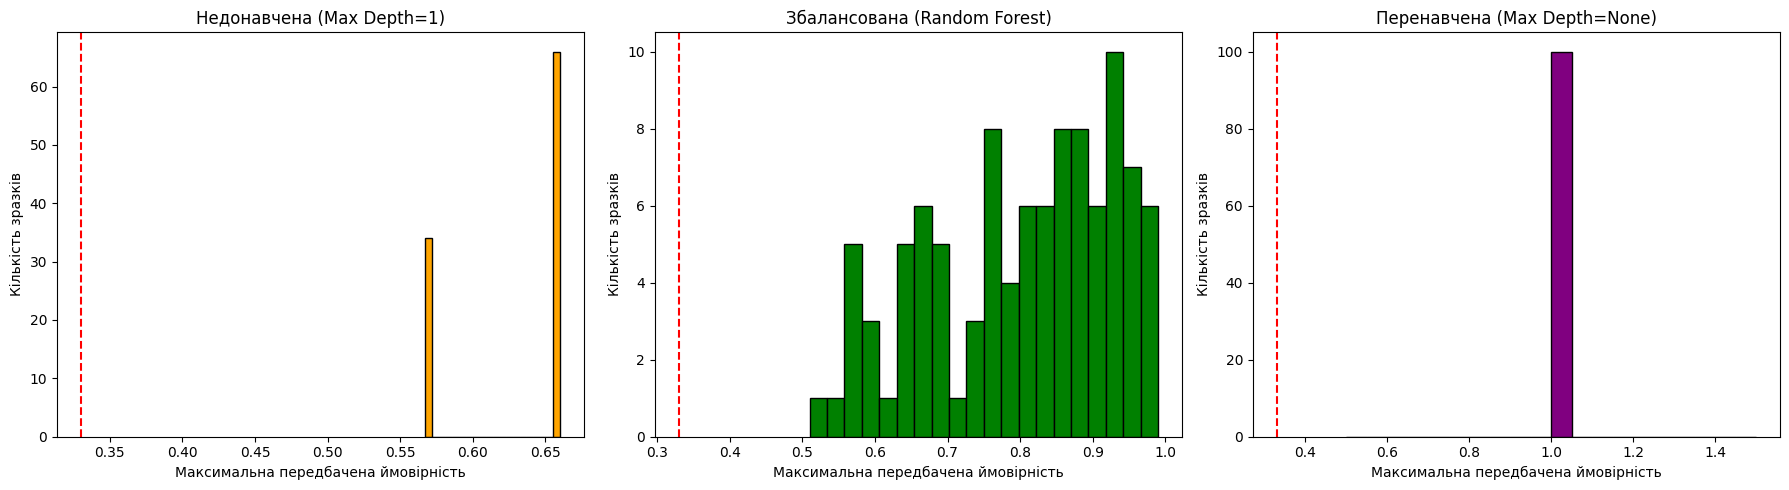

In [20]:
rf_clf = RandomForestClassifier(random_state=42).fit(x_train, y_train_cls)
under_clf = DecisionTreeClassifier(max_depth=1, random_state=42).fit(x_train, y_train_cls)
over_clf = DecisionTreeClassifier(max_depth=None, random_state=42).fit(x_train, y_train_cls)

conf_rf = np.max(rf_clf.predict_proba(x_test), axis=1)
conf_under = np.max(under_clf.predict_proba(x_test), axis=1)
conf_over = np.max(over_clf.predict_proba(x_test), axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(conf_under, bins=20, color='orange', edgecolor='black')
axes[0].set_title("Недонавчена (Max Depth=1)")
axes[0].axvline(0.33, color='red', linestyle='--')

axes[1].hist(conf_rf, bins=20, color='green', edgecolor='black')
axes[1].set_title("Збалансована (Random Forest)")
axes[1].axvline(0.33, color='red', linestyle='--')

axes[2].hist(conf_over, bins=20, color='purple', edgecolor='black')
axes[2].set_title("Перенавчена (Max Depth=None)")
axes[2].axvline(0.33, color='red', linestyle='--')

for ax in axes:
    ax.set_xlabel("Максимальна передбачена ймовірність")
    ax.set_ylabel("Кількість зразків")

plt.tight_layout()
plt.show()

6. Гіперпараметричний тюнінг
Спробуємо покращити результати Random Forest класифікатора, підібравши оптимальні параметри через GridSearchCV.

In [14]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(x_train, y_train_cls)
best_rf = grid_search.best_estimator_

print("Найкращі параметри:", grid_search.best_params_)
print("Точність до оптимізації:", accuracy_score(y_test_cls, rf_clf.predict(x_test)))
print("Точність після оптимізації:", accuracy_score(y_test_cls, best_rf.predict(x_test)))

Найкращі параметри: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Точність до оптимізації: 0.88
Точність після оптимізації: 0.94


7. Фінальний висновок: Регресія чи Класифікація?
Для визначення того, що спрацювало краще, ми конвертуємо прогнози нашої регресійної моделі у класи та порівняємо з результатами чистих класифікаторів.

In [15]:
ridge_pred = models['Ridge (Baseline)'].predict(x_test)

discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')
y_test_2d = y_test.values.reshape(-1, 1)
y_test_kbins = discretizer.fit_transform(y_test_2d).flatten()

pred_ridge_kbins = discretizer.transform(ridge_pred.reshape(-1, 1)).flatten()

reg_as_class_acc = accuracy_score(y_test_kbins, pred_ridge_kbins)
best_clf_acc = accuracy_score(y_test_cls, best_rf.predict(x_test))

print(f"Точність регресії, зведеної до класів: {reg_as_class_acc * 100:.2f}%")
print(f"Точність найкращого класифікатора: {best_clf_acc * 100:.2f}%")

Точність регресії, зведеної до класів: 100.00%
Точність найкращого класифікатора: 94.00%


Загальний підсумок
Що краще (Bagging, Boosting чи Stacking)?
Ансамблеві методи (особливо Gradient Boosting та Stacking) суттєво перевершують базові лінійні моделі в задачі регресії, 
оскільки здатні враховувати складні нелінійні зв'язки між площею, кількістю мешканців та температурою.

Регресія vs Класифікація:

Регресія є природним і найкращим вибором для цієї задачі.
Енергоспоживання — це неперервна величина.
Регресійні моделі (особливо ансамблі) зберігають максимум інформації з даних і видають високоточні прогнози з мінімальним відхиленням.

Класифікація штучно "обрізає" дані (дискретизація), втрачаючи інформацію про різницю всередині самого класу (наприклад, споживання 100 кВт і 300 кВт можуть потрапити в один клас "Низьке", хоча різниця величезна).

Висновок: Для аналізу енергоспоживання регресія справляється значно краще. 
Переходити до класифікації має сенс виключно тоді, коли бізнес-задача жорстко вимагає лише спрацьовування тригерів 
    (наприклад, "Увімкнути режим економії, якщо прогнозується Високе споживання").